# 23 - FCNN Front-Only 4-Class

**Dataset:** Front-only 4-Class
**3 Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionFCNN
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)})")

Device: cuda
GPU: Tesla T4)


In [2]:
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "4class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 4
EMOTIONS = ["neutral", "happy", "sad", "negative"]

print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_4class
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class


In [3]:
print("Loading landmark data...")
def load_dataloaders(dataset_dir, batch_size=32):
    train_ds = EmotionLandmarkDataset(dataset_dir / "X_train_landmarks.npy", dataset_dir / "y_train.npy")
    val_ds = EmotionLandmarkDataset(dataset_dir / "X_val_landmarks.npy", dataset_dir / "y_val.npy")
    test_ds = EmotionLandmarkDataset(dataset_dir / "X_test_landmarks.npy", dataset_dir / "y_test.npy")
    train_l = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_l = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_l = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return train_l, val_l, test_l

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Loading landmark data...
Train: 5348 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
    negative: 114


## Skenario B1: Baseline

Model parameters: 597,380

Training FCNN B1 - Baseline (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9898     0.6875     0.7462    0.9378   0.2420   0.000100  (1.2s)


     2      0.7711     0.7801     0.5671    0.9378   0.2420   0.000100  (1.0s)


     3      0.7091     0.7842     0.4818    0.9406   0.3090   0.000100  (1.2s)


     4      0.6548     0.7926     0.3287    0.9406   0.3534   0.000100  (1.0s)


...

    21      0.5256     0.8160     0.2260    0.9448   0.4345   0.000050  (1.0s)


    22      0.5099     0.8252     0.2299    0.9448   0.4214   0.000050  (1.0s)


    23      0.5132     0.8199     0.2348    0.9448   0.4518   0.000050  (1.0s)


    24      0.5078     0.8220     0.2500    0.9392   0.3474   0.000050  (1.1s)


    25      0.5102     0.8255     0.2195    0.9448   0.4667   0.000050  (1.0s)

Early stopping at epoch 25. Best epoch: 10 (val_f1=0.5036)

Best: epoch 10, val_acc=0.9406, val_f1=0.5036
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/fcnn_b1.pth


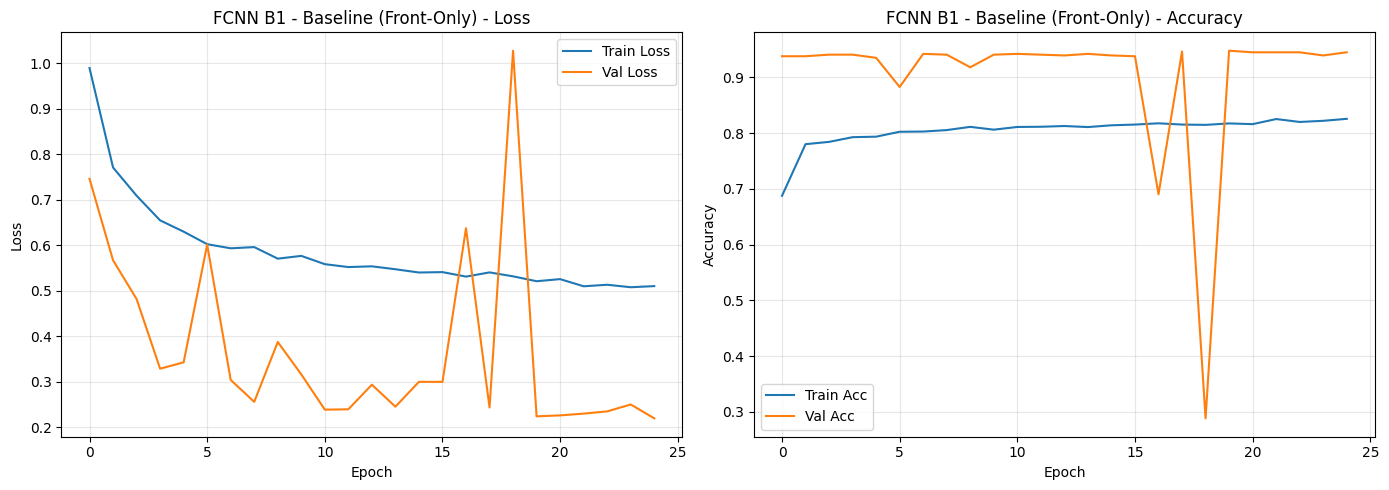

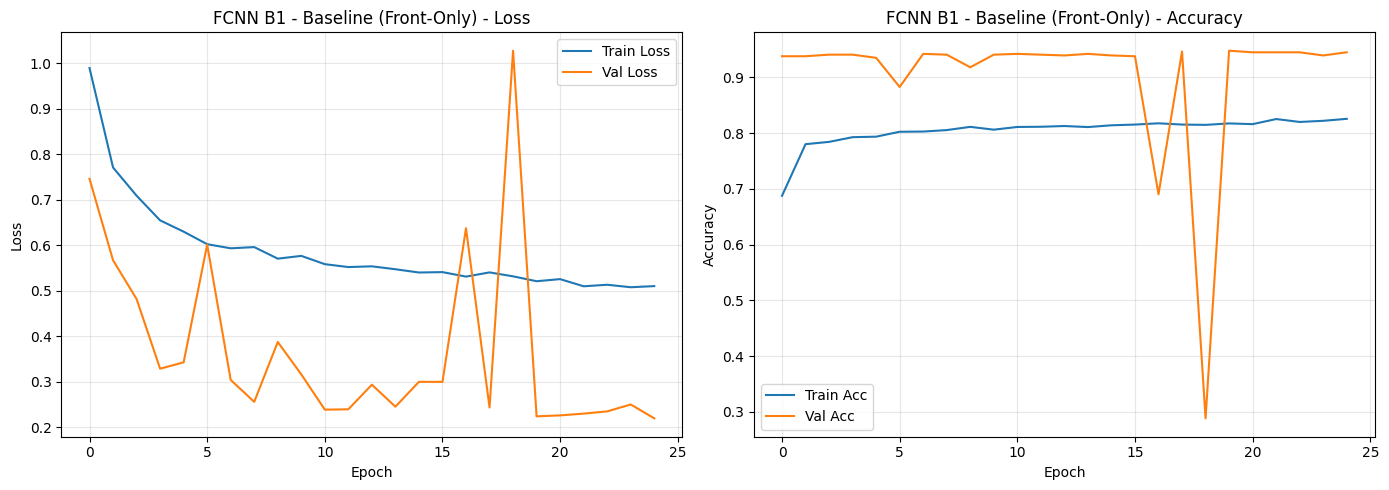

In [4]:
# B1: Baseline
criterion = nn.CrossEntropyLoss()

model = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining FCNN B1 - Baseline (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "fcnn_b1.pth"))

plot_training_history(history, "FCNN B1 - Baseline (Front-Only)")

EVALUASI B1 - BASELINE


Test Loss: 0.4838
Test Accuracy: 0.8967
Test Macro F1: 0.3072
Test Weighted F1: 0.9006

Classification Report:
              precision    recall  f1-score   support

     neutral       0.95      0.94      0.95       981
       happy       0.19      0.30      0.23        10
         sad       0.04      0.07      0.05        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.90      1036
   macro avg       0.30      0.33      0.31      1036
weighted avg       0.90      0.90      0.90      1036



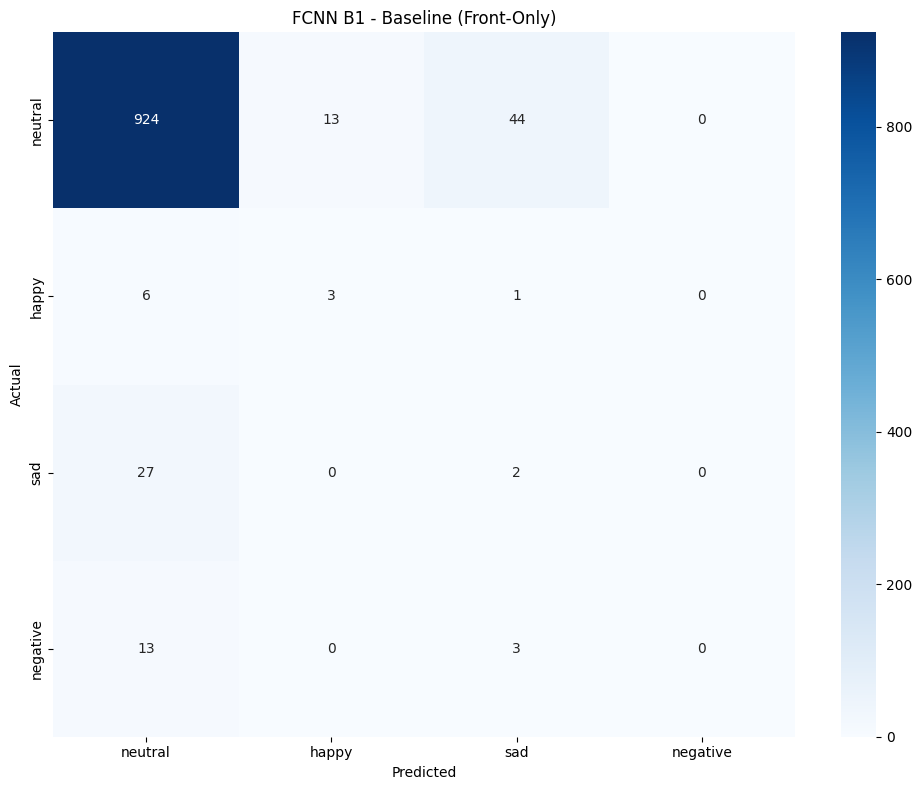

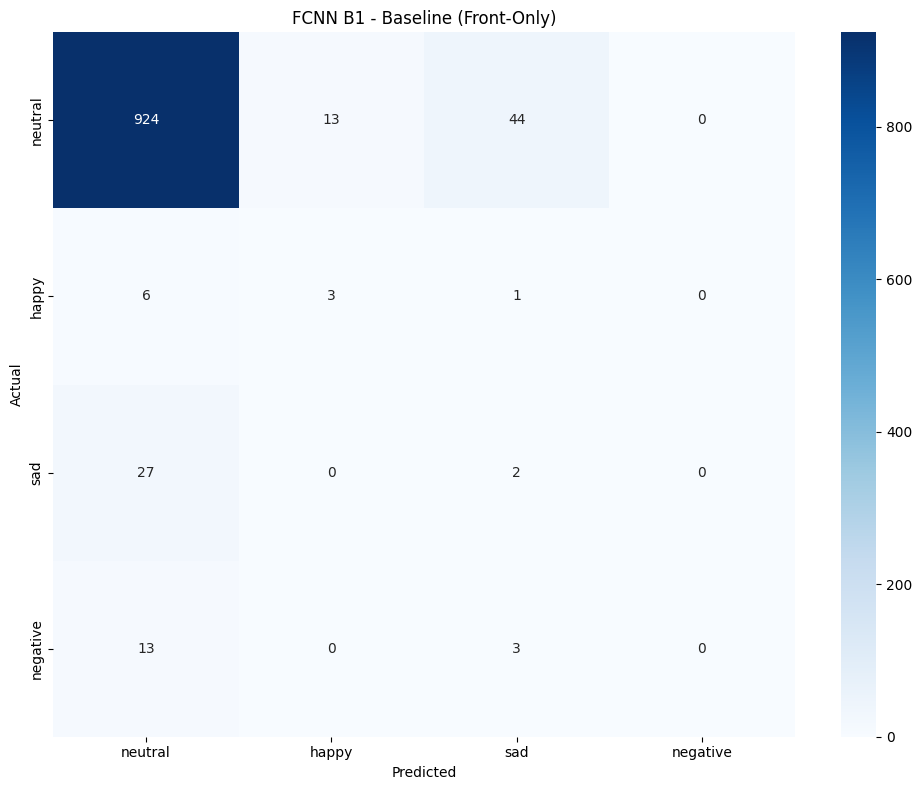

In [5]:
# Evaluate B1
model.load_state_dict(torch.load(OUTPUT_DIR / "fcnn_b1.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model, test_loader, criterion, device, "fcnn", EMOTIONS)
plot_confusion_matrix(results_b1["confusion_matrix"], "FCNN B1 - Baseline (Front-Only)", emotions=EMOTIONS)

## Skenario B2: Class Weights

Class weights: None
Model parameters: 597,380

Training FCNN B2 - Class Weights (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9189     0.7378     0.7298    0.9264   0.2405   0.000100  (1.0s)


     2      0.7437     0.7799     0.5002    0.9321   0.2412   0.000100  (0.9s)


     3      0.6759     0.7906     0.3440    0.9392   0.2779   0.000100  (1.0s)


     4      0.6383     0.7975     0.4991    0.9406   0.3727   0.000100  (1.0s)


...

    27      0.5016     0.8250     0.2535    0.9406   0.3919   0.000050  (1.0s)


    28      0.4962     0.8276     0.2797    0.9420   0.4500   0.000050  (1.1s)


    29      0.4985     0.8287     0.2502    0.9406   0.3919   0.000050  (1.0s)


    30      0.4997     0.8244     0.2591    0.9448   0.4551   0.000050  (1.0s)


    31      0.4947     0.8283     0.3389    0.9349   0.4872   0.000050  (1.0s)

Early stopping at epoch 31. Best epoch: 16 (val_f1=0.5049)

Best: epoch 16, val_acc=0.9434, val_f1=0.5049
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/fcnn_b2.pth


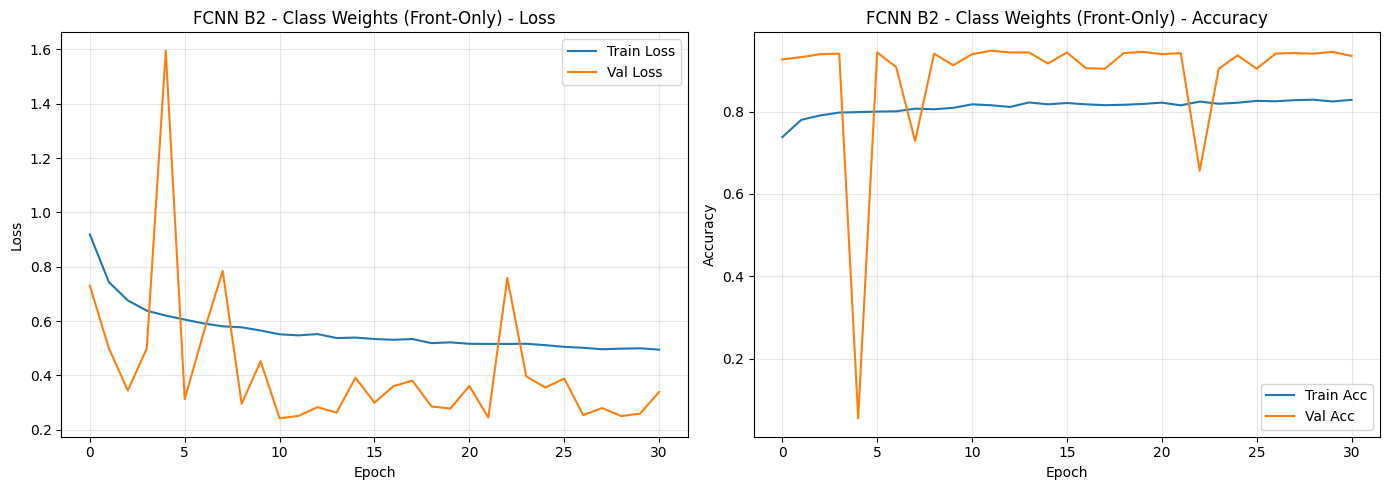

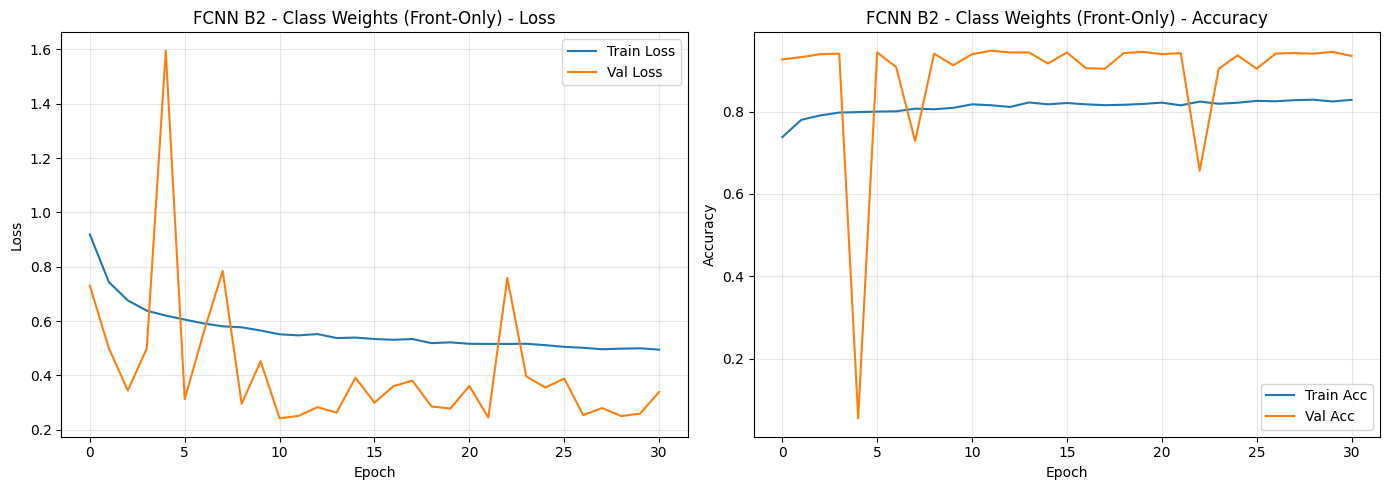

In [6]:
# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")
criterion = nn.CrossEntropyLoss(weight=weights)

model = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining FCNN B2 - Class Weights (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "fcnn_b2.pth"))

plot_training_history(history, "FCNN B2 - Class Weights (Front-Only)")

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.4835
Test Accuracy: 0.8417
Test Macro F1: 0.2448
Test Weighted F1: 0.8722

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.88      0.92       981
       happy       0.03      0.40      0.06        10
         sad       0.00      0.00      0.00        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.84      1036
   macro avg       0.25      0.32      0.24      1036
weighted avg       0.91      0.84      0.87      1036



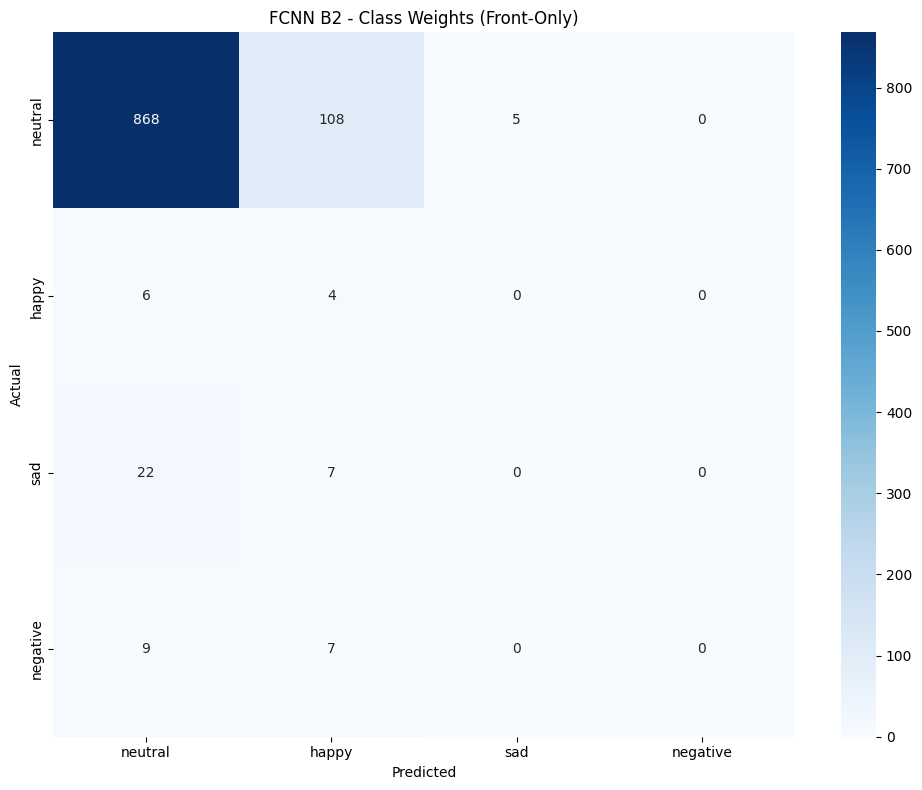

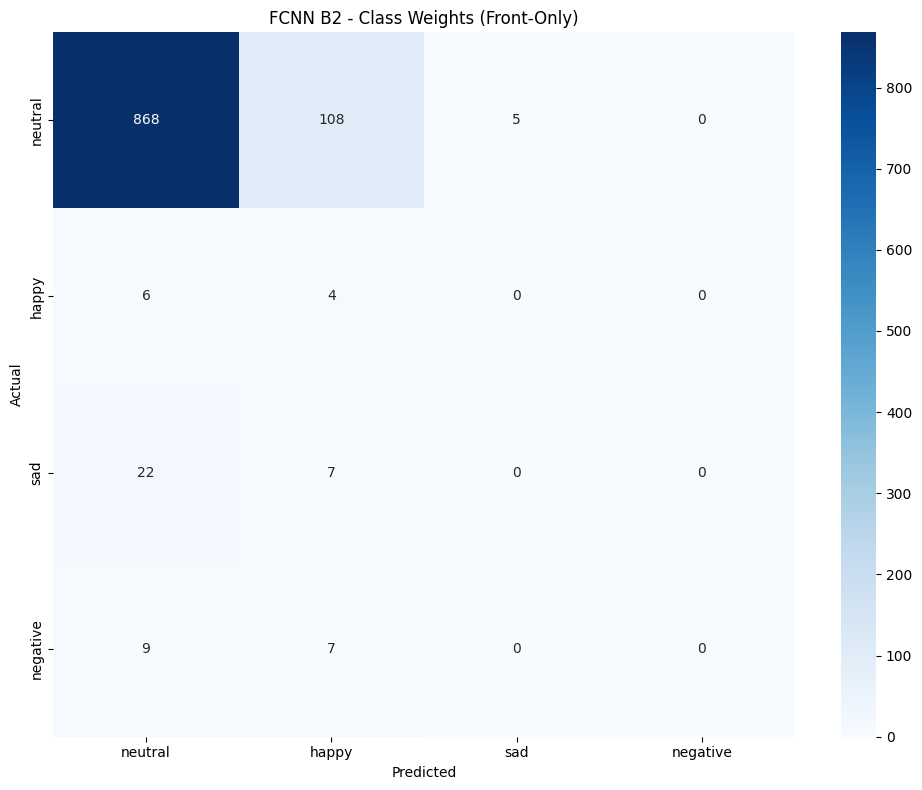

In [7]:
# Evaluate B2
model.load_state_dict(torch.load(OUTPUT_DIR / "fcnn_b2.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model, test_loader, criterion, device, "fcnn", EMOTIONS)
plot_confusion_matrix(results_b2["confusion_matrix"], "FCNN B2 - Class Weights (Front-Only)", emotions=EMOTIONS)

## Skenario B3: Class Weights + Augmentasi

Train: 5834 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
    negative: 600
Augmented class weights: None
Model parameters: 597,380

Training FCNN B3 - Weights + Augmentasi (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.2223     0.4633     0.8566    0.9208   0.2397   0.000100  (1.2s)


     2      0.8803     0.7261     0.5901    0.9349   0.2416   0.000100  (1.1s)


     3      0.7995     0.7422     0.4871    0.9349   0.2416   0.000100  (1.0s)


     4      0.7601     0.7494     0.6577    0.9123   0.3107   0.000100  (1.1s)


...

    46      0.5258     0.8067     0.2698    0.9448   0.4058   0.000050  (1.2s)


    47      0.5262     0.8073     0.2510    0.9434   0.4103   0.000050  (1.1s)


    48      0.5202     0.8096     0.2379    0.9434   0.4269   0.000050  (1.2s)


    49      0.5265     0.8060     0.2486    0.9463   0.4531   0.000050  (1.3s)


    50      0.5255     0.8080     0.2387    0.9463   0.4378   0.000025  (1.2s)

Best: epoch 40, val_acc=0.9406, val_f1=0.5194
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/fcnn_b3.pth


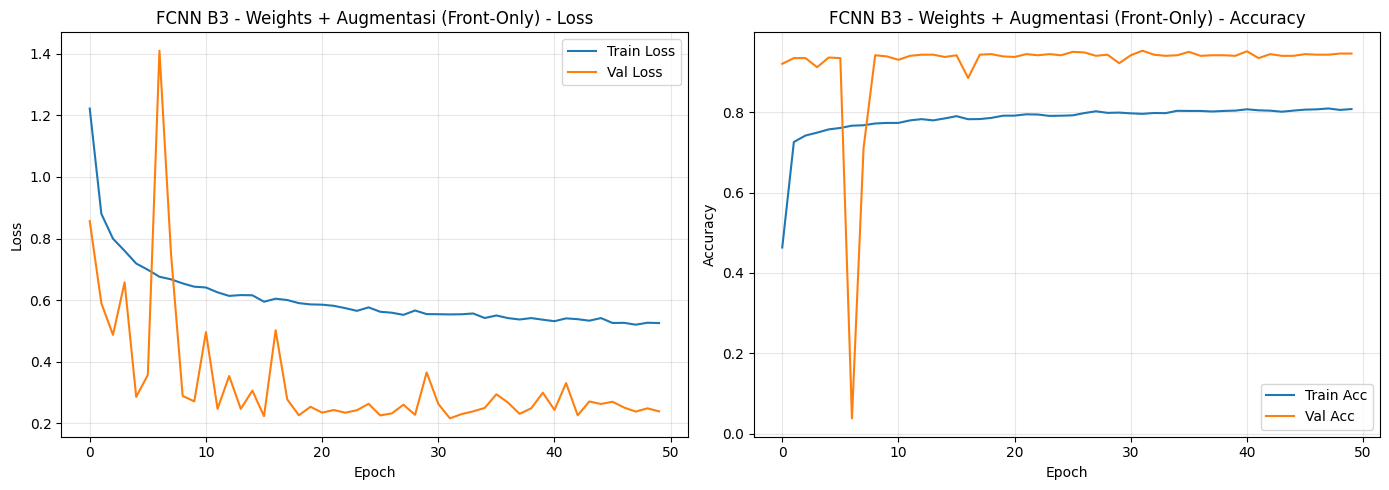

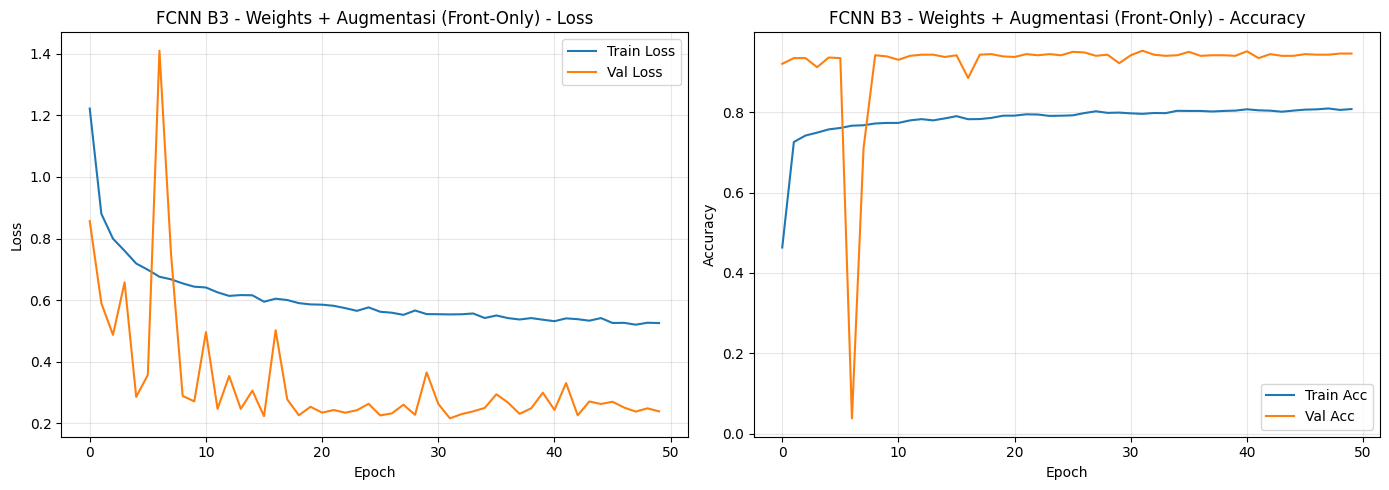

In [8]:
# B3: Weights + Augmentasi
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")
criterion = nn.CrossEntropyLoss(weight=weights_aug)

model = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining FCNN B3 - Weights + Augmentasi (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader_aug, val_loader, criterion, optimizer, scheduler,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "fcnn_b3.pth"))

plot_training_history(history, "FCNN B3 - Weights + Augmentasi (Front-Only)")

EVALUASI B3 - WEIGHTS + AUGMENTASI


Test Loss: 0.4175
Test Accuracy: 0.8938
Test Macro F1: 0.3614
Test Weighted F1: 0.9087

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.93      0.95       981
       happy       0.09      0.50      0.16        10
         sad       0.40      0.07      0.12        29
    negative       0.15      0.38      0.22        16

    accuracy                           0.89      1036
   macro avg       0.41      0.47      0.36      1036
weighted avg       0.94      0.89      0.91      1036



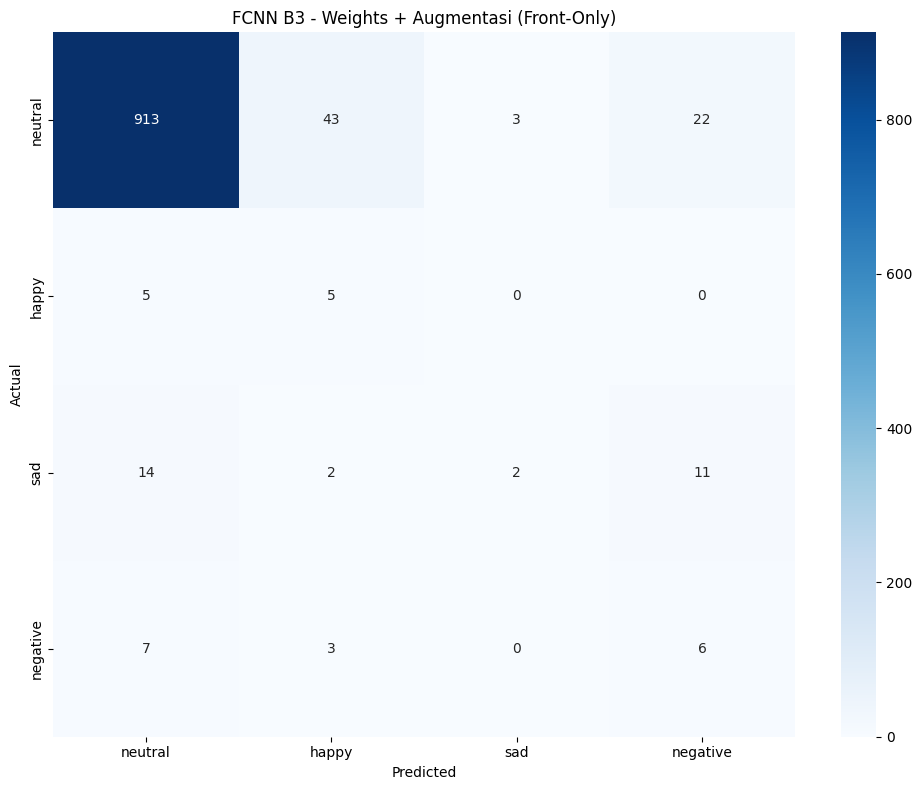

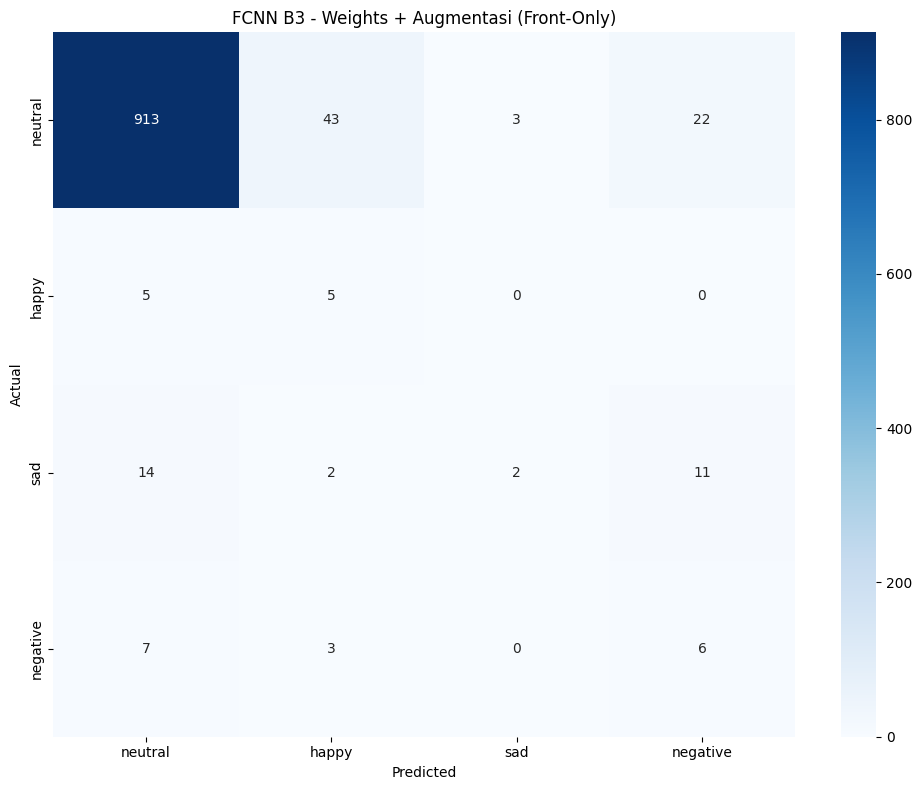

In [9]:
# Evaluate B3
model.load_state_dict(torch.load(OUTPUT_DIR / "fcnn_b3.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B3 - WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model, test_loader, criterion, device, "fcnn", EMOTIONS)
plot_confusion_matrix(results_b3["confusion_matrix"], "FCNN B3 - Weights + Augmentasi (Front-Only)", emotions=EMOTIONS)

## Perbandingan 3 Skenario

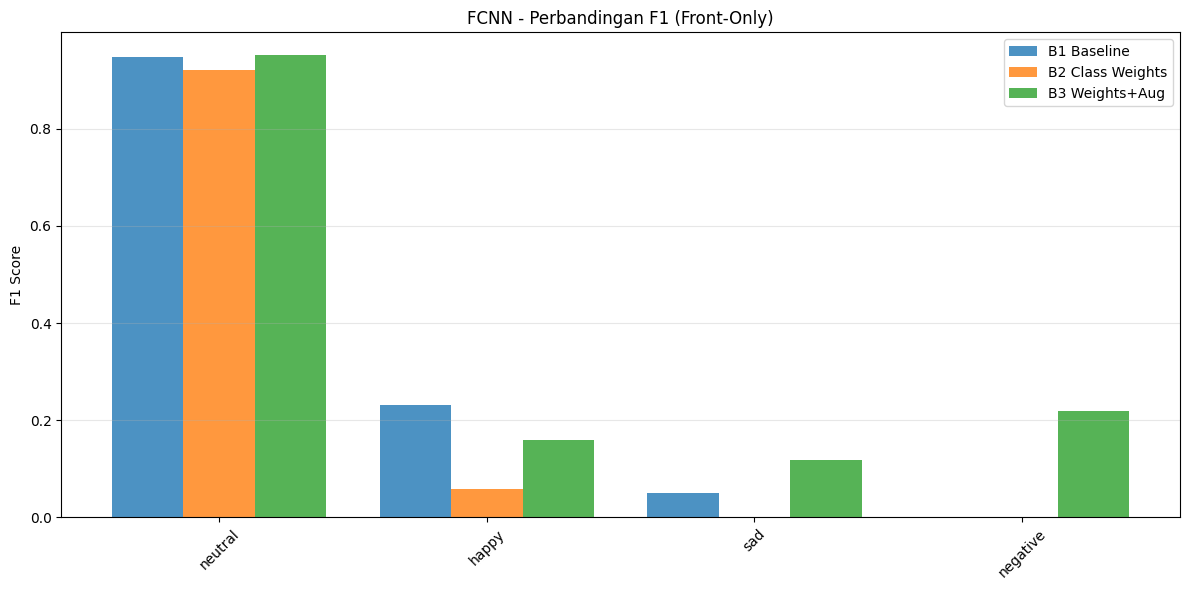

RINGKASAN FCNN FRONT-ONLY
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.8967     0.3072       0.9006
B2 Class Weights              0.8417     0.2448       0.8722
B3 Weights+Aug                0.8938     0.3614       0.9087

Saved to /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/fcnn_results.json


In [10]:
# Perbandingan
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "FCNN - Perbandingan F1 (Front-Only)", emotions=EMOTIONS)

print("=" * 70)
print("RINGKASAN FCNN FRONT-ONLY")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

results_save = {}
for name, r in all_results.items():
    results_save[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "fcnn_results.json", "w") as f:
    json.dump(results_save, f, indent=2)
print(f"\nSaved to {OUTPUT_DIR / 'fcnn_results.json'}")